# Heart Disease Classification Using Machine Learning



## 1. Install the required package

In [1]:
!pip install -q ucimlrepo


## 2. Import libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")


## 3. Fetch the dataset

In [3]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)


Feature data shape: (303, 13)
Target data shape: (303, 1)


## 4. Metadata and variable information

In [4]:
print("DATASET METADATA")
print("-" * 80)
print(heart_disease.metadata)


DATASET METADATA
--------------------------------------------------------------------------------
{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm f

In [5]:
print("VARIABLE INFORMATION")
print("-" * 80)
display(heart_disease.variables)


VARIABLE INFORMATION
--------------------------------------------------------------------------------


,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


## 5. Combine predictors and target

In [6]:
print("Target column(s):", y.columns.tolist())

df = pd.concat([X, y], axis=1)

print("Combined dataset shape:", df.shape)
display(df.head())


Target column(s): ['num']
Combined dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.30,3,0.00,6.00,0
1,67,1,4,160,286,0,2,108,1,1.50,2,3.00,3.00,2
2,67,1,4,120,229,0,2,129,1,2.60,2,2.00,7.00,1
3,37,1,3,130,250,0,0,187,0,3.50,3,0.00,3.00,0
4,41,0,2,130,204,0,2,172,0,1.40,1,0.00,3.00,0


## 6. Basic data checks

In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())


Number of rows: 303
Number of columns: 14

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [8]:
print("DATA TYPES")
display(df.dtypes.to_frame(name="Data Type"))


DATA TYPES


,Data Type
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [10]:
display(df.head())
display(df.tail())


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.30,3,0.00,6.00,0
1,67,1,4,160,286,0,2,108,1,1.50,2,3.00,3.00,2
2,67,1,4,120,229,0,2,129,1,2.60,2,2.00,7.00,1
3,37,1,3,130,250,0,0,187,0,3.50,3,0.00,3.00,0
4,41,0,2,130,204,0,2,172,0,1.40,1,0.00,3.00,0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
298,45,1,1,110,264,0,0,132,0,1.20,2,0.00,7.00,1
299,68,1,4,144,193,1,0,141,0,3.40,2,2.00,7.00,2
300,57,1,4,130,131,0,0,115,1,1.20,2,1.00,7.00,3
301,57,0,2,130,236,0,2,174,0,0.00,2,1.00,3.00,1
302,38,1,3,138,175,0,0,173,0,0.00,1,NaN,3.00,0


## 7. Missing-value analysis

In [11]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
}).sort_values("Missing Values", ascending=False)

display(missing_summary)


,Missing Values,Missing Percentage
ca,4,1.32
thal,2,0.66
cp,0,0.00
trestbps,0,0.00
age,0,0.00
sex,0,0.00
fbs,0,0.00
chol,0,0.00
restecg,0,0.00
thalach,0,0.00


In [12]:
missing_only = missing_summary[missing_summary["Missing Values"] > 0]

missing_only


,Missing Values,Missing Percentage
ca,4,1.32
thal,2,0.66


## 8. Duplicate-record check

In [13]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)])
else:
    print("No duplicate rows were found.")


Number of duplicate rows: 0
No duplicate rows were found.


## 9. Unique-value check

In [14]:
unique_summary = pd.DataFrame({
    "Unique Values": df.nunique(dropna=False)
}).sort_values("Unique Values")

display(unique_summary)


,Unique Values
sex,2
fbs,2
exang,2
restecg,3
slope,3
thal,4
cp,4
ca,5
num,5
oldpeak,40


In [15]:
low_cardinality_columns = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 10
]

for col in low_cardinality_columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).sort_index())



sex
sex
0     97
1    206
Name: count, dtype: int64

cp
cp
1     23
2     50
3     86
4    144
Name: count, dtype: int64

fbs
fbs
0    258
1     45
Name: count, dtype: int64

restecg
restecg
0    151
1      4
2    148
Name: count, dtype: int64

exang
exang
0    204
1     99
Name: count, dtype: int64

slope
slope
1    142
2    140
3     21
Name: count, dtype: int64

ca
ca
0.00    176
1.00     65
2.00     38
3.00     20
NaN       4
Name: count, dtype: int64

thal
thal
3.00    166
6.00     18
7.00    117
NaN       2
Name: count, dtype: int64

num
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


## 10. Prepare the binary target

In [16]:
target_column = y.columns[0]

print("Original target column:", target_column)
print("\nOriginal target distribution:")
print(df[target_column].value_counts(dropna=False).sort_index())

df["heart_disease_binary"] = np.where(df[target_column] > 0, 1, 0)

print("\nBinary target distribution:")
print(df["heart_disease_binary"].value_counts().sort_index())

print("\nBinary target percentages:")
print((df["heart_disease_binary"].value_counts(normalize=True).sort_index() * 100).round(2))


Original target column: num

Original target distribution:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Binary target distribution:
heart_disease_binary
0    164
1    139
Name: count, dtype: int64

Binary target percentages:
heart_disease_binary
0   54.13
1   45.87
Name: proportion, dtype: float64


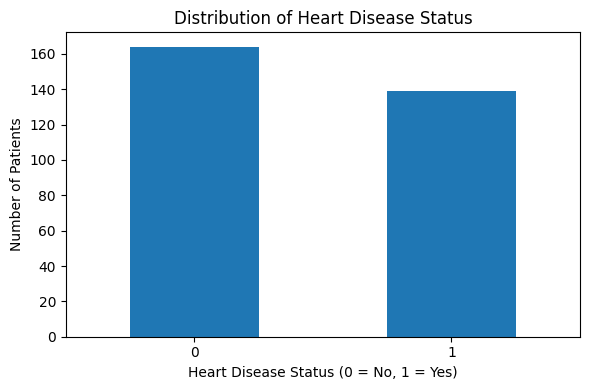

In [17]:
target_counts = df["heart_disease_binary"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Distribution of Heart Disease Status")
plt.xlabel("Heart Disease Status (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 11. Descriptive statistics

In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
display(df[numeric_columns].describe().T)


,count,mean,std,min,25%,50%,75%,max
age,303.00,54.44,9.04,29.00,48.00,56.00,61.00,77.00
sex,303.00,0.68,0.47,0.00,0.00,1.00,1.00,1.00
cp,303.00,3.16,0.96,1.00,3.00,3.00,4.00,4.00
trestbps,303.00,131.69,17.60,94.00,120.00,130.00,140.00,200.00
chol,303.00,246.69,51.78,126.00,211.00,241.00,275.00,564.00
fbs,303.00,0.15,0.36,0.00,0.00,0.00,0.00,1.00
restecg,303.00,0.99,0.99,0.00,0.00,1.00,2.00,2.00
thalach,303.00,149.61,22.88,71.00,133.50,153.00,166.00,202.00
exang,303.00,0.33,0.47,0.00,0.00,0.00,1.00,1.00
oldpeak,303.00,1.04,1.16,0.00,0.00,0.80,1.60,6.20


In [19]:
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

if categorical_columns:
    display(df[categorical_columns].describe().T)
else:
    print("No non-numeric columns were identified.")


No non-numeric columns were identified.


## 12. Univariate analysis

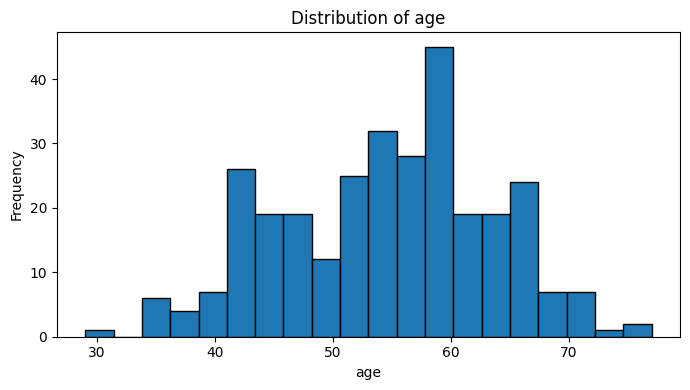

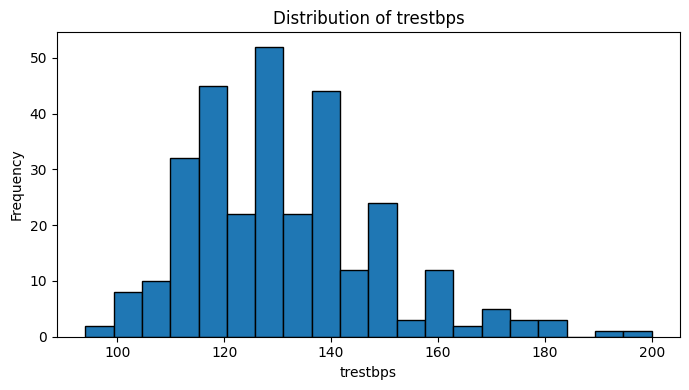

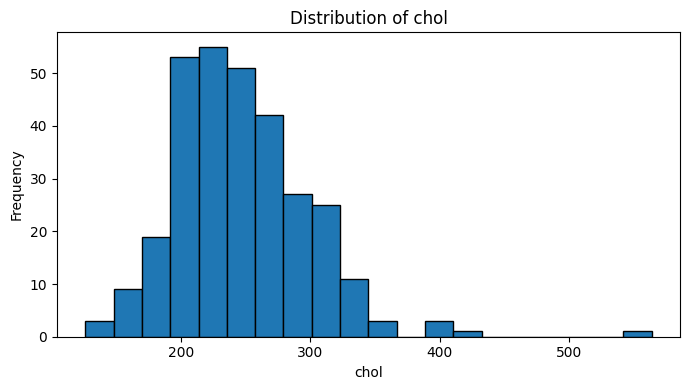

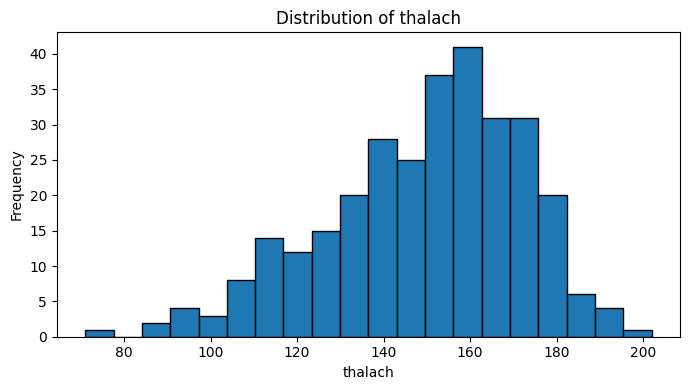

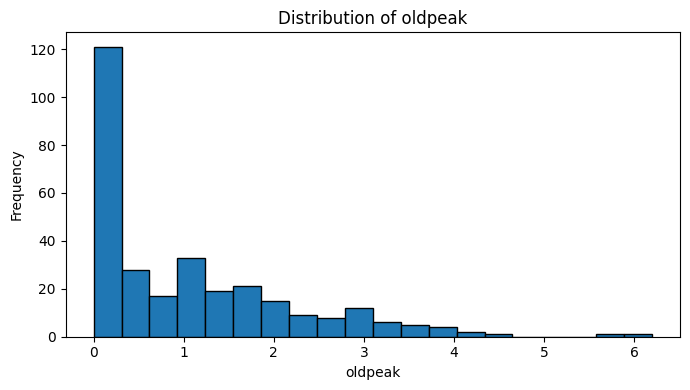

In [20]:
selected_numeric = [
    col for col in ["age", "trestbps", "chol", "thalach", "oldpeak"]
    if col in df.columns
]

for col in selected_numeric:
    plt.figure(figsize=(7, 4))
    df[col].dropna().plot(kind="hist", bins=20, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


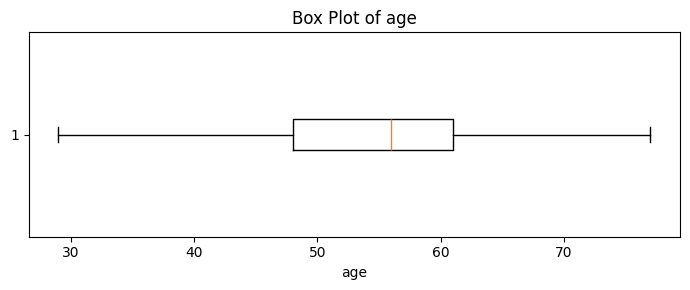

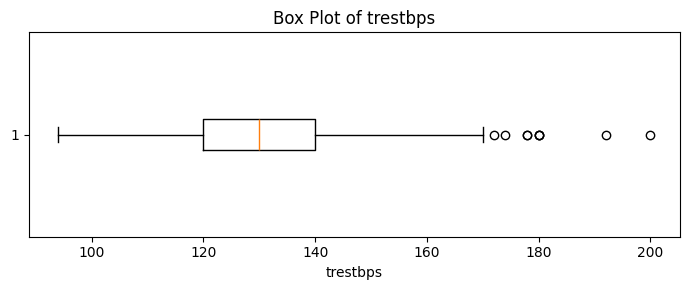

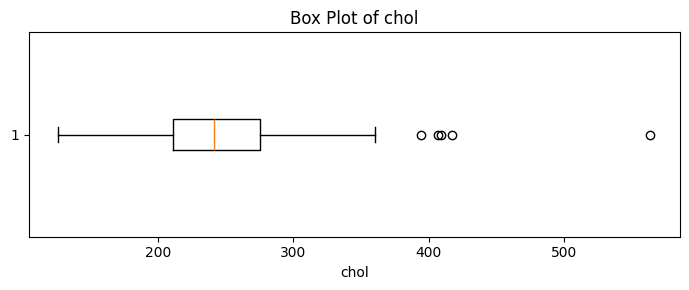

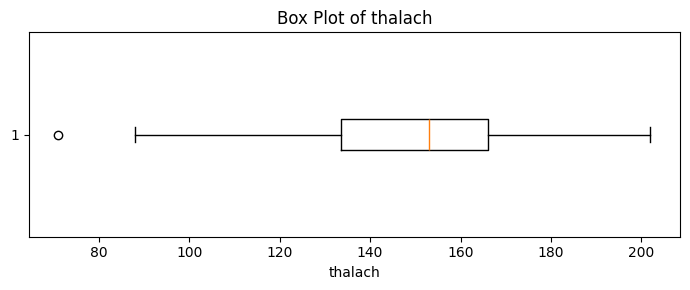

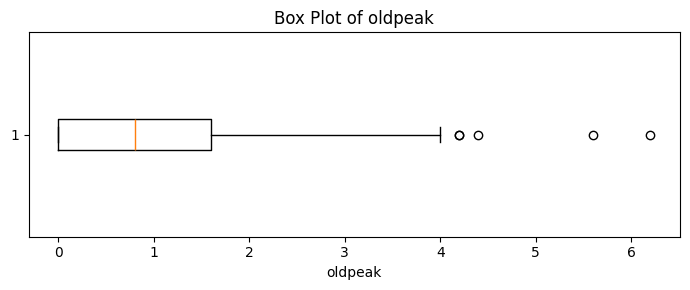

In [21]:
for col in selected_numeric:
    plt.figure(figsize=(7, 3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Box Plot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


## 13. Bivariate analysis

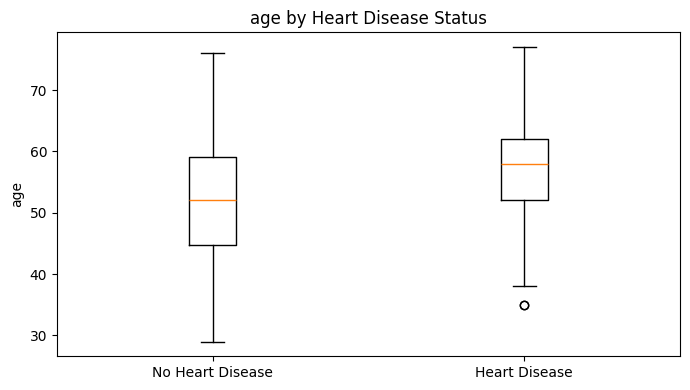

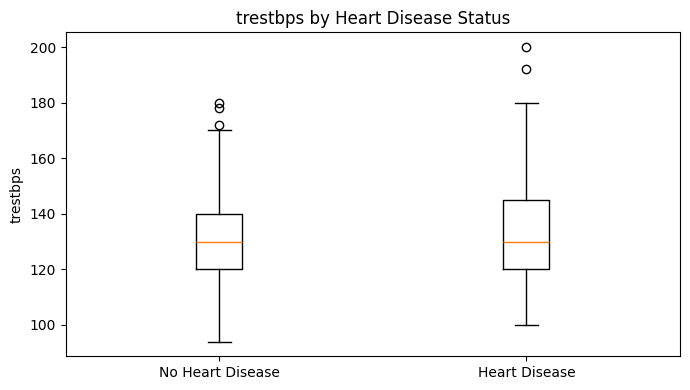

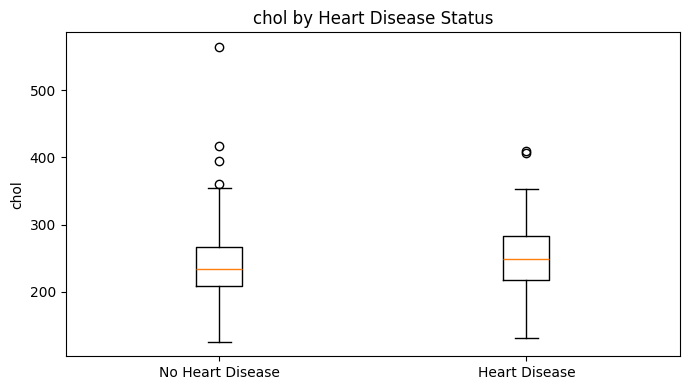

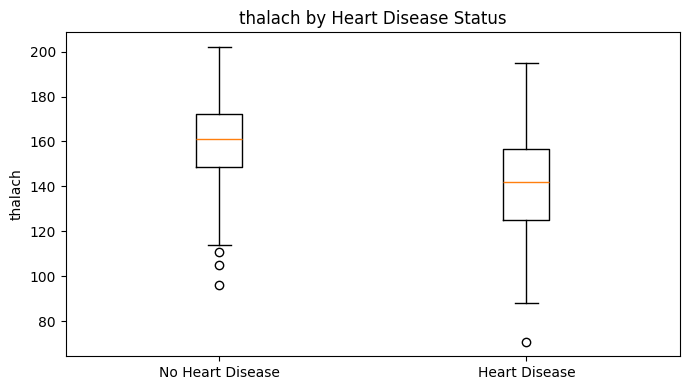

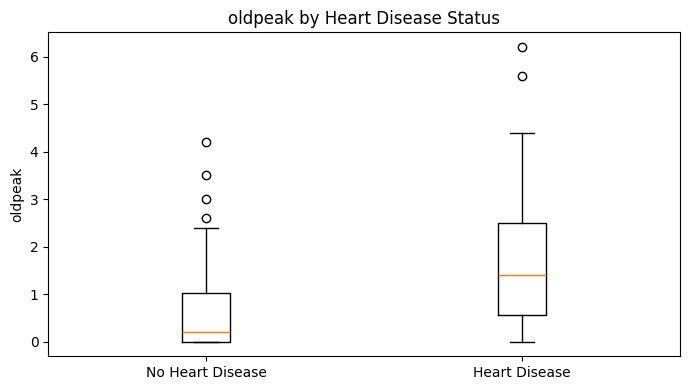

In [22]:
for col in selected_numeric:
    group_0 = df.loc[df["heart_disease_binary"] == 0, col].dropna()
    group_1 = df.loc[df["heart_disease_binary"] == 1, col].dropna()

    plt.figure(figsize=(7, 4))
    plt.boxplot([group_0, group_1], labels=["No Heart Disease", "Heart Disease"])
    plt.title(f"{col} by Heart Disease Status")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()



Percentage distribution of heart disease by sex


heart_disease_binary,0,1
sex,,
0,74.23,25.77
1,44.66,55.34


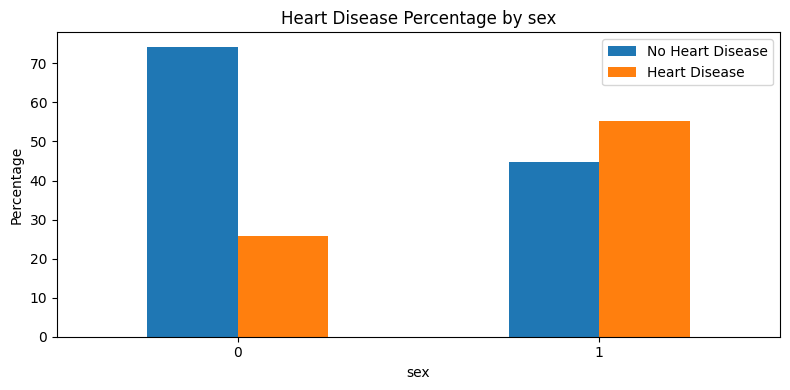


Percentage distribution of heart disease by cp


heart_disease_binary,0,1
cp,,
1,69.57,30.43
2,82.00,18.00
3,79.07,20.93
4,27.08,72.92


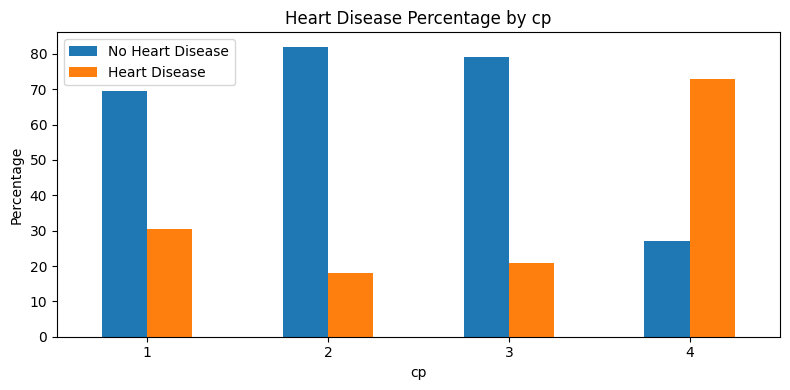


Percentage distribution of heart disease by fbs


heart_disease_binary,0,1
fbs,,
0,54.65,45.35
1,51.11,48.89


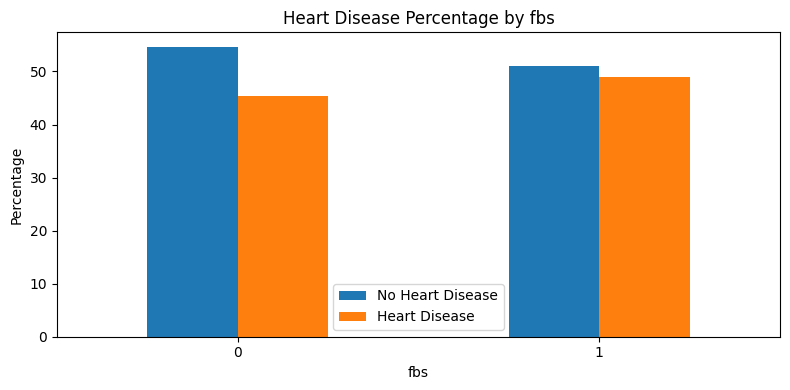


Percentage distribution of heart disease by restecg


heart_disease_binary,0,1
restecg,,
0,62.91,37.09
1,25.00,75.00
2,45.95,54.05


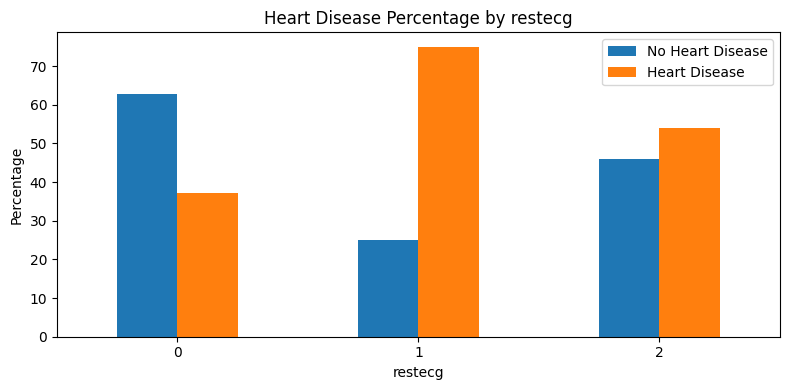


Percentage distribution of heart disease by exang


heart_disease_binary,0,1
exang,,
0,69.12,30.88
1,23.23,76.77


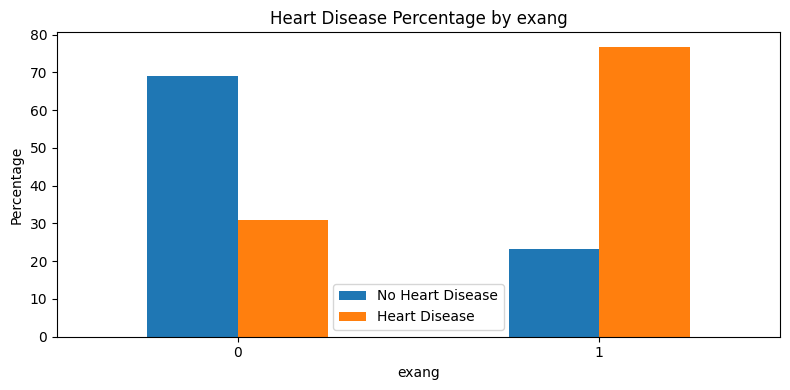


Percentage distribution of heart disease by slope


heart_disease_binary,0,1
slope,,
1,74.65,25.35
2,35.00,65.00
3,42.86,57.14


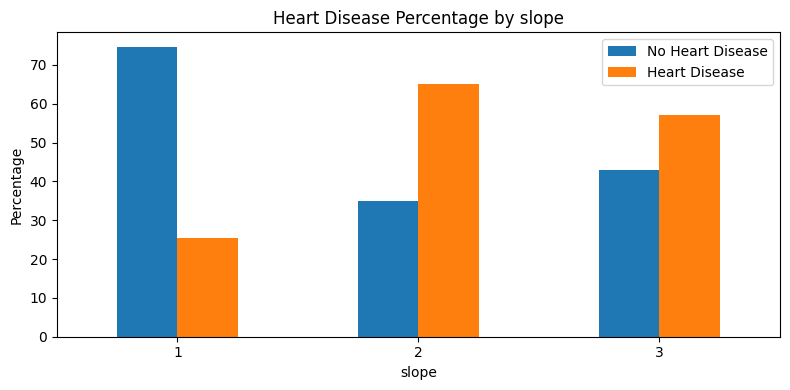


Percentage distribution of heart disease by ca


heart_disease_binary,0,1
ca,,
0.00,73.86,26.14
1.00,32.31,67.69
2.00,18.42,81.58
3.00,15.00,85.00


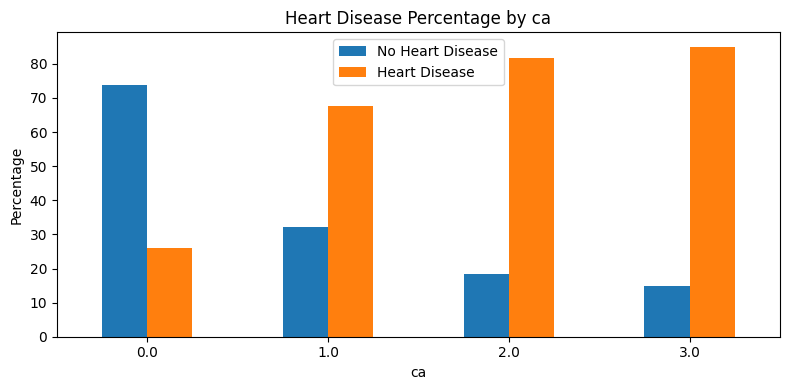


Percentage distribution of heart disease by thal


heart_disease_binary,0,1
thal,,
3.00,77.71,22.29
6.00,33.33,66.67
7.00,23.93,76.07


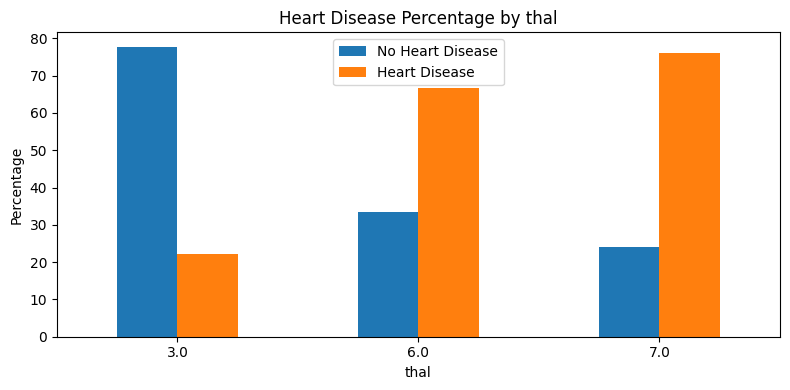

In [23]:
selected_categorical = [
    col for col in ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
    if col in df.columns
]

for col in selected_categorical:
    cross_tab = pd.crosstab(
        df[col],
        df["heart_disease_binary"],
        normalize="index"
    ) * 100

    print(f"\nPercentage distribution of heart disease by {col}")
    display(cross_tab.round(2))

    cross_tab.plot(kind="bar", figsize=(8, 4))
    plt.title(f"Heart Disease Percentage by {col}")
    plt.xlabel(col)
    plt.ylabel("Percentage")
    plt.xticks(rotation=0)
    plt.legend(["No Heart Disease", "Heart Disease"])
    plt.tight_layout()
    plt.show()


## 14. Correlation analysis

In [24]:
correlation_matrix = df[numeric_columns].corr()
display(correlation_matrix.round(2))


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,heart_disease_binary
age,1.00,-0.10,0.10,0.28,0.21,0.12,0.15,-0.39,0.09,0.20,0.16,0.36,0.13,0.22,0.22
sex,-0.10,1.00,0.01,-0.06,-0.20,0.05,0.02,-0.05,0.15,0.10,0.04,0.09,0.38,0.22,0.28
cp,0.10,0.01,1.00,-0.04,0.07,-0.04,0.07,-0.33,0.38,0.20,0.15,0.23,0.27,0.41,0.41
trestbps,0.28,-0.06,-0.04,1.00,0.13,0.18,0.15,-0.05,0.06,0.19,0.12,0.10,0.13,0.16,0.15
chol,0.21,-0.20,0.07,0.13,1.00,0.01,0.17,-0.00,0.06,0.05,-0.00,0.12,0.01,0.07,0.09
fbs,0.12,0.05,-0.04,0.18,0.01,1.00,0.07,-0.01,0.03,0.01,0.06,0.15,0.07,0.06,0.03
restecg,0.15,0.02,0.07,0.15,0.17,0.07,1.00,-0.08,0.08,0.11,0.13,0.13,0.02,0.18,0.17
thalach,-0.39,-0.05,-0.33,-0.05,-0.00,-0.01,-0.08,1.00,-0.38,-0.34,-0.39,-0.26,-0.28,-0.42,-0.42
exang,0.09,0.15,0.38,0.06,0.06,0.03,0.08,-0.38,1.00,0.29,0.26,0.15,0.33,0.40,0.43
oldpeak,0.20,0.10,0.20,0.19,0.05,0.01,0.11,-0.34,0.29,1.00,0.58,0.30,0.34,0.50,0.42


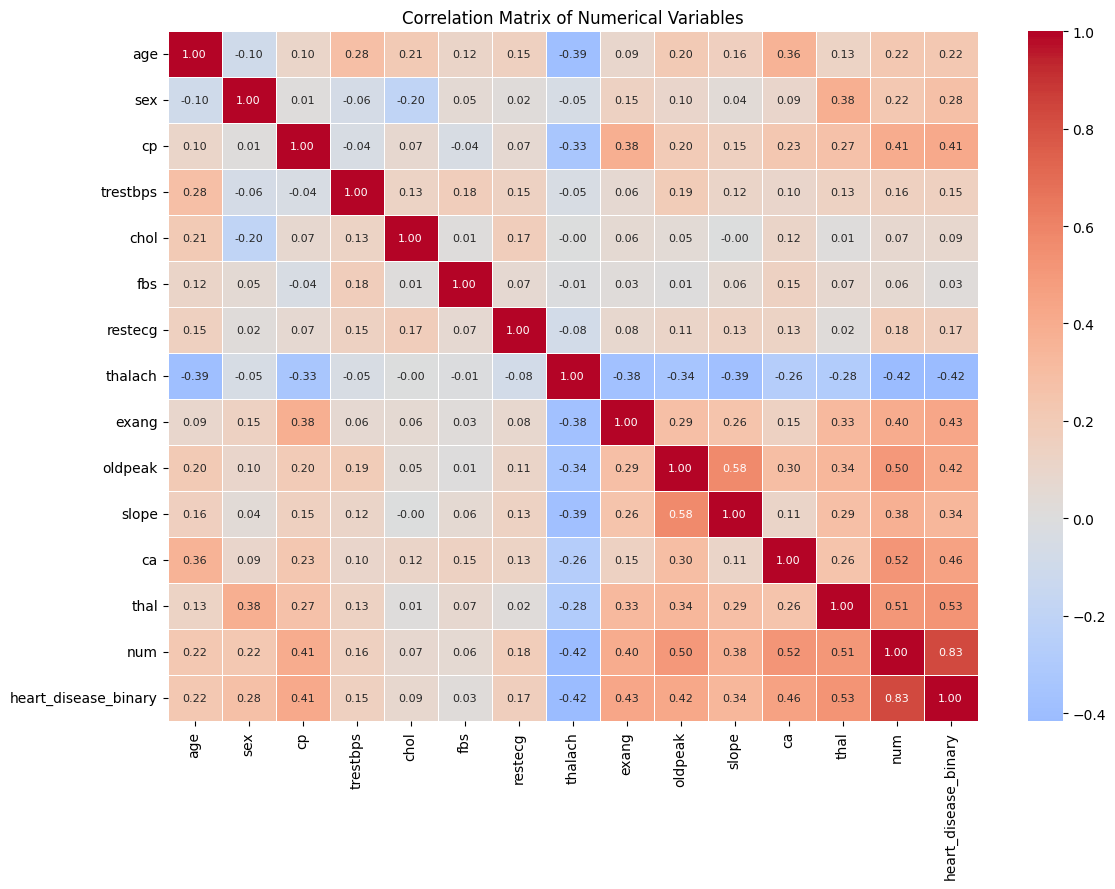

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar=True
)

plt.title("Correlation Matrix of Numerical Variables")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
target_correlations = (
    correlation_matrix["heart_disease_binary"]
    .drop("heart_disease_binary")
    .sort_values(key=abs, ascending=False)
)

display(target_correlations.to_frame(name="Correlation with Binary Target"))


,Correlation with Binary Target
num,0.83
thal,0.53
ca,0.46
exang,0.43
oldpeak,0.42
thalach,-0.42
cp,0.41
slope,0.34
sex,0.28
age,0.22


15. Separate Predictors and Binary Target

In [27]:
# Original target column from the UCI dataset
original_target_column = y.columns[0]

# Predictors
X_model = df.drop(
    columns=[original_target_column, "heart_disease_binary"]
)

# Binary target
y_model = df["heart_disease_binary"]

print("Predictor shape:", X_model.shape)
print("Target shape:", y_model.shape)

display(X_model.head())
display(y_model.head())

Predictor shape: (303, 13)
Target shape: (303,)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.30,3,0.00,6.00
1,67,1,4,160,286,0,2,108,1,1.50,2,3.00,3.00
2,67,1,4,120,229,0,2,129,1,2.60,2,2.00,7.00
3,37,1,3,130,250,0,0,187,0,3.50,3,0.00,3.00
4,41,0,2,130,204,0,2,172,0,1.40,1,0.00,3.00


,heart_disease_binary
0,0
1,1
2,1
3,0
4,0


16. Identify Numerical and Categorical Columns

In [28]:
# Numerical columns
numerical_columns = X_model.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Treat low-cardinality coded variables as categorical
categorical_columns = [
    col for col in ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
    if col in X_model.columns
]

# Remove categorical columns from the numerical list
numerical_columns = [
    col for col in numerical_columns
    if col not in categorical_columns
]

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Categorical columns:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


## 17. Train-Test Split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=42,
    stratify=y_model
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

X_train shape: (242, 13)
X_test shape: (61, 13)
y_train shape: (242,)
y_test shape: (61,)

Training target distribution:
heart_disease_binary
0   0.54
1   0.46
Name: proportion, dtype: float64

Testing target distribution:
heart_disease_binary
0   0.54
1   0.46
Name: proportion, dtype: float64


## 18. Build the Preprocessing Pipeline

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical features: impute missing values with the median and standardise
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical features: impute missing values with the most frequent value and one-hot encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_columns),
    ("cat", categorical_transformer, categorical_columns)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 19. Import Model-Evaluation Libraries and Create Result Containers



In [31]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    roc_curve
)

results = []
fitted_models = {}
predictions_by_model = {}
probabilities_by_model = {}

print("Model-evaluation libraries and result containers are ready.")


Model-evaluation libraries and result containers are ready.


## 20.1 Logistic Regression


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.89,0.84,0.93,0.88,0.97


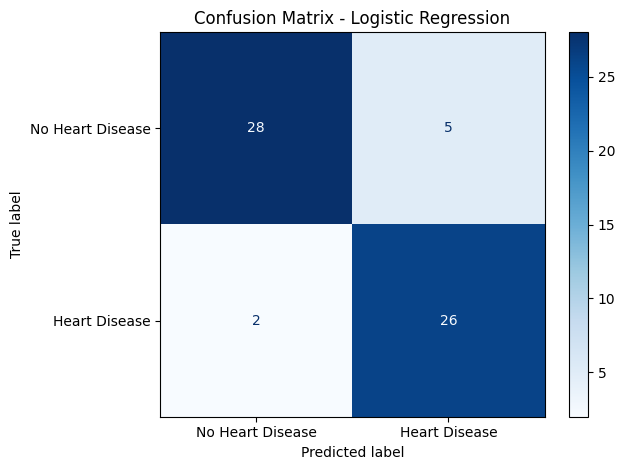

In [32]:
# Build and train the Logistic Regression model
logistic_regression_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_regression_pipeline.fit(X_train, y_train)

# Generate test-set class predictions and probabilities
logistic_regression_predictions = logistic_regression_pipeline.predict(X_test)
logistic_regression_probabilities = logistic_regression_pipeline.predict_proba(X_test)[:, 1]

# Calculate the required test-set evaluation metrics
logistic_regression_accuracy = accuracy_score(y_test, logistic_regression_predictions)
logistic_regression_precision = precision_score(y_test, logistic_regression_predictions, zero_division=0)
logistic_regression_recall = recall_score(y_test, logistic_regression_predictions, zero_division=0)
logistic_regression_f1 = f1_score(y_test, logistic_regression_predictions, zero_division=0)
logistic_regression_roc_auc = roc_auc_score(y_test, logistic_regression_probabilities)

logistic_regression_result = {
    "Model": "Logistic Regression",
    "Accuracy": logistic_regression_accuracy,
    "Precision": logistic_regression_precision,
    "Recall": logistic_regression_recall,
    "F1-Score": logistic_regression_f1,
    "ROC-AUC": logistic_regression_roc_auc
}

results.append(logistic_regression_result)
fitted_models["Logistic Regression"] = logistic_regression_pipeline
predictions_by_model["Logistic Regression"] = logistic_regression_predictions
probabilities_by_model["Logistic Regression"] = logistic_regression_probabilities

display(pd.DataFrame([logistic_regression_result]).round(3))

# Visualise the confusion matrix before moving to the next model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_regression_predictions,
    display_labels=["No Heart Disease", "Heart Disease"],
    values_format="d",
    cmap="Blues"
)
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()


## 20.2 Decision Tree


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.79,0.74,0.82,0.78,0.86


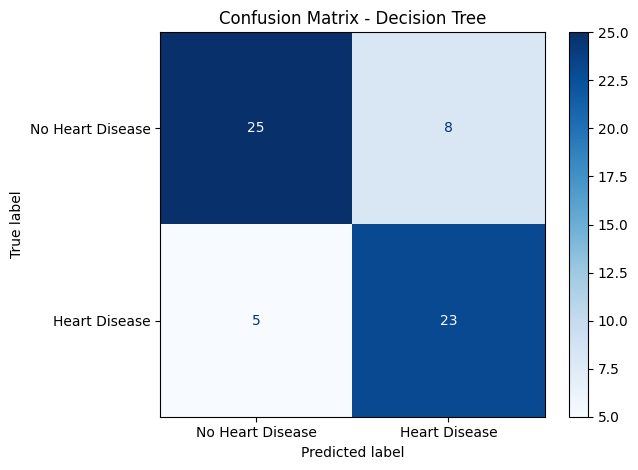

In [33]:
# Build and train the Decision Tree model
decision_tree_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", DecisionTreeClassifier(max_depth=4, random_state=42))
])

decision_tree_pipeline.fit(X_train, y_train)

# Generate test-set class predictions and probabilities
decision_tree_predictions = decision_tree_pipeline.predict(X_test)
decision_tree_probabilities = decision_tree_pipeline.predict_proba(X_test)[:, 1]

# Calculate the required test-set evaluation metrics
decision_tree_accuracy = accuracy_score(y_test, decision_tree_predictions)
decision_tree_precision = precision_score(y_test, decision_tree_predictions, zero_division=0)
decision_tree_recall = recall_score(y_test, decision_tree_predictions, zero_division=0)
decision_tree_f1 = f1_score(y_test, decision_tree_predictions, zero_division=0)
decision_tree_roc_auc = roc_auc_score(y_test, decision_tree_probabilities)

decision_tree_result = {
    "Model": "Decision Tree",
    "Accuracy": decision_tree_accuracy,
    "Precision": decision_tree_precision,
    "Recall": decision_tree_recall,
    "F1-Score": decision_tree_f1,
    "ROC-AUC": decision_tree_roc_auc
}

results.append(decision_tree_result)
fitted_models["Decision Tree"] = decision_tree_pipeline
predictions_by_model["Decision Tree"] = decision_tree_predictions
probabilities_by_model["Decision Tree"] = decision_tree_probabilities

display(pd.DataFrame([decision_tree_result]).round(3))

# Visualise the confusion matrix before moving to the next model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    decision_tree_predictions,
    display_labels=["No Heart Disease", "Heart Disease"],
    values_format="d",
    cmap="Blues"
)
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()


## 20.3 Random Forest


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.87,0.81,0.93,0.87,0.94


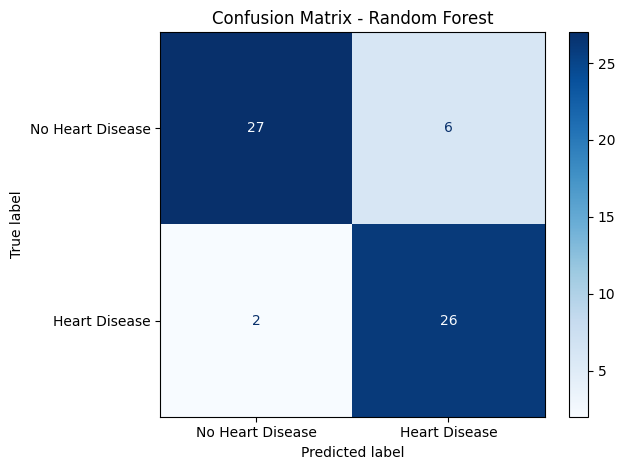

In [34]:
# Build and train the Random Forest model
random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42))
])

random_forest_pipeline.fit(X_train, y_train)

# Generate test-set class predictions and probabilities
random_forest_predictions = random_forest_pipeline.predict(X_test)
random_forest_probabilities = random_forest_pipeline.predict_proba(X_test)[:, 1]

# Calculate the required test-set evaluation metrics
random_forest_accuracy = accuracy_score(y_test, random_forest_predictions)
random_forest_precision = precision_score(y_test, random_forest_predictions, zero_division=0)
random_forest_recall = recall_score(y_test, random_forest_predictions, zero_division=0)
random_forest_f1 = f1_score(y_test, random_forest_predictions, zero_division=0)
random_forest_roc_auc = roc_auc_score(y_test, random_forest_probabilities)

random_forest_result = {
    "Model": "Random Forest",
    "Accuracy": random_forest_accuracy,
    "Precision": random_forest_precision,
    "Recall": random_forest_recall,
    "F1-Score": random_forest_f1,
    "ROC-AUC": random_forest_roc_auc
}

results.append(random_forest_result)
fitted_models["Random Forest"] = random_forest_pipeline
predictions_by_model["Random Forest"] = random_forest_predictions
probabilities_by_model["Random Forest"] = random_forest_probabilities

display(pd.DataFrame([random_forest_result]).round(3))

# Visualise the confusion matrix before moving to the next model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    random_forest_predictions,
    display_labels=["No Heart Disease", "Heart Disease"],
    values_format="d",
    cmap="Blues"
)
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()


## 20.4 K-Nearest Neighbours


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,K-Nearest Neighbours,0.89,0.86,0.89,0.88,0.95


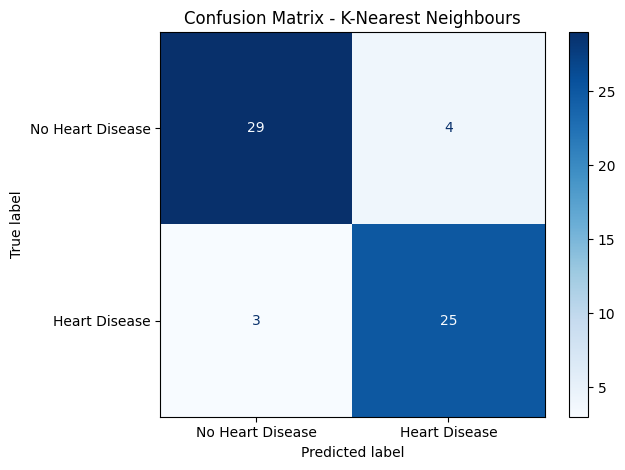

In [35]:
# Build and train the K-Nearest Neighbours model
knn_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)

# Generate test-set class predictions and probabilities
knn_predictions = knn_pipeline.predict(X_test)
knn_probabilities = knn_pipeline.predict_proba(X_test)[:, 1]

# Calculate the required test-set evaluation metrics
knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_precision = precision_score(y_test, knn_predictions, zero_division=0)
knn_recall = recall_score(y_test, knn_predictions, zero_division=0)
knn_f1 = f1_score(y_test, knn_predictions, zero_division=0)
knn_roc_auc = roc_auc_score(y_test, knn_probabilities)

knn_result = {
    "Model": "K-Nearest Neighbours",
    "Accuracy": knn_accuracy,
    "Precision": knn_precision,
    "Recall": knn_recall,
    "F1-Score": knn_f1,
    "ROC-AUC": knn_roc_auc
}

results.append(knn_result)
fitted_models["K-Nearest Neighbours"] = knn_pipeline
predictions_by_model["K-Nearest Neighbours"] = knn_predictions
probabilities_by_model["K-Nearest Neighbours"] = knn_probabilities

display(pd.DataFrame([knn_result]).round(3))

# Visualise the confusion matrix before moving to the next model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_predictions,
    display_labels=["No Heart Disease", "Heart Disease"],
    values_format="d",
    cmap="Blues"
)
plt.title("Confusion Matrix - K-Nearest Neighbours")
plt.tight_layout()
plt.show()


## 20.5 Support Vector Machine


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Support Vector Machine,0.89,0.84,0.93,0.88,0.96


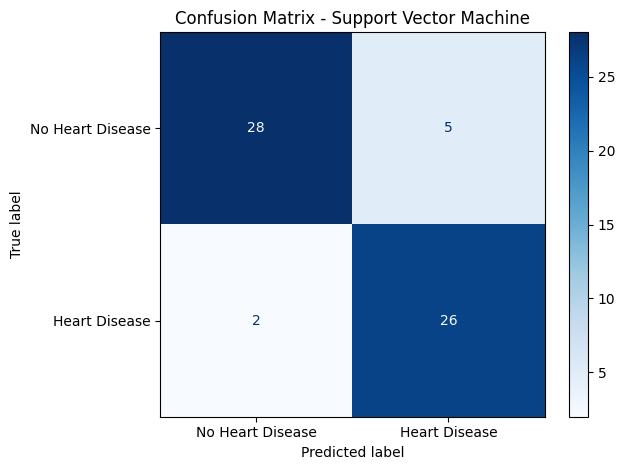

In [36]:
# Build and train the Support Vector Machine model
svm_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", SVC(kernel="rbf", probability=True, random_state=42))
])

svm_pipeline.fit(X_train, y_train)

# Generate test-set class predictions and probabilities
svm_predictions = svm_pipeline.predict(X_test)
svm_probabilities = svm_pipeline.predict_proba(X_test)[:, 1]

# Calculate the required test-set evaluation metrics
svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions, zero_division=0)
svm_recall = recall_score(y_test, svm_predictions, zero_division=0)
svm_f1 = f1_score(y_test, svm_predictions, zero_division=0)
svm_roc_auc = roc_auc_score(y_test, svm_probabilities)

svm_result = {
    "Model": "Support Vector Machine",
    "Accuracy": svm_accuracy,
    "Precision": svm_precision,
    "Recall": svm_recall,
    "F1-Score": svm_f1,
    "ROC-AUC": svm_roc_auc
}

results.append(svm_result)
fitted_models["Support Vector Machine"] = svm_pipeline
predictions_by_model["Support Vector Machine"] = svm_predictions
probabilities_by_model["Support Vector Machine"] = svm_probabilities

display(pd.DataFrame([svm_result]).round(3))

# Visualise the confusion matrix before moving to the next model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_predictions,
    display_labels=["No Heart Disease", "Heart Disease"],
    values_format="d",
    cmap="Blues"
)
plt.title("Confusion Matrix - Support Vector Machine")
plt.tight_layout()
plt.show()


## 20.6 Gradient Boosting


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.89,0.84,0.93,0.88,0.95


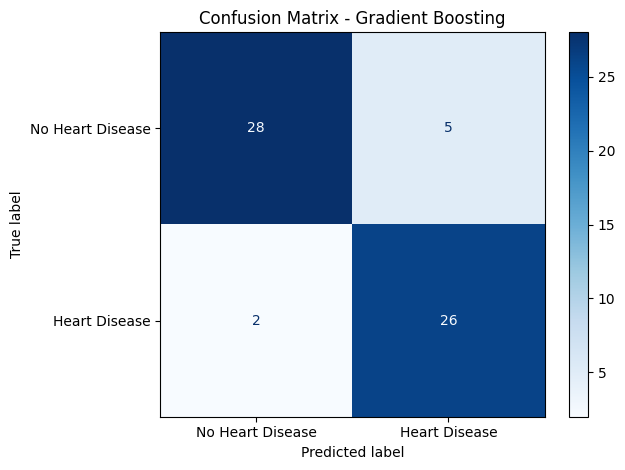

In [37]:
# Build and train the Gradient Boosting model
gradient_boosting_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42))
])

gradient_boosting_pipeline.fit(X_train, y_train)

# Generate test-set class predictions and probabilities
gradient_boosting_predictions = gradient_boosting_pipeline.predict(X_test)
gradient_boosting_probabilities = gradient_boosting_pipeline.predict_proba(X_test)[:, 1]

# Calculate the required test-set evaluation metrics
gradient_boosting_accuracy = accuracy_score(y_test, gradient_boosting_predictions)
gradient_boosting_precision = precision_score(y_test, gradient_boosting_predictions, zero_division=0)
gradient_boosting_recall = recall_score(y_test, gradient_boosting_predictions, zero_division=0)
gradient_boosting_f1 = f1_score(y_test, gradient_boosting_predictions, zero_division=0)
gradient_boosting_roc_auc = roc_auc_score(y_test, gradient_boosting_probabilities)

gradient_boosting_result = {
    "Model": "Gradient Boosting",
    "Accuracy": gradient_boosting_accuracy,
    "Precision": gradient_boosting_precision,
    "Recall": gradient_boosting_recall,
    "F1-Score": gradient_boosting_f1,
    "ROC-AUC": gradient_boosting_roc_auc
}

results.append(gradient_boosting_result)
fitted_models["Gradient Boosting"] = gradient_boosting_pipeline
predictions_by_model["Gradient Boosting"] = gradient_boosting_predictions
probabilities_by_model["Gradient Boosting"] = gradient_boosting_probabilities

display(pd.DataFrame([gradient_boosting_result]).round(3))

# Visualise the confusion matrix before moving to the next model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    gradient_boosting_predictions,
    display_labels=["No Heart Disease", "Heart Disease"],
    values_format="d",
    cmap="Blues"
)
plt.title("Confusion Matrix - Gradient Boosting")
plt.tight_layout()
plt.show()


## 20.7 Neural Network


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Neural Network,0.87,0.83,0.89,0.86,0.94


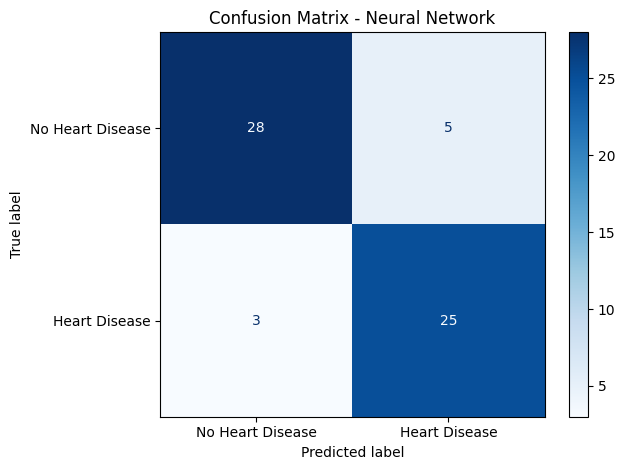

In [38]:
# Build and train the Neural Network model
neural_network_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", solver="adam", max_iter=2000, early_stopping=True, random_state=42))
])

neural_network_pipeline.fit(X_train, y_train)

# Generate test-set class predictions and probabilities
neural_network_predictions = neural_network_pipeline.predict(X_test)
neural_network_probabilities = neural_network_pipeline.predict_proba(X_test)[:, 1]

# Calculate the required test-set evaluation metrics
neural_network_accuracy = accuracy_score(y_test, neural_network_predictions)
neural_network_precision = precision_score(y_test, neural_network_predictions, zero_division=0)
neural_network_recall = recall_score(y_test, neural_network_predictions, zero_division=0)
neural_network_f1 = f1_score(y_test, neural_network_predictions, zero_division=0)
neural_network_roc_auc = roc_auc_score(y_test, neural_network_probabilities)

neural_network_result = {
    "Model": "Neural Network",
    "Accuracy": neural_network_accuracy,
    "Precision": neural_network_precision,
    "Recall": neural_network_recall,
    "F1-Score": neural_network_f1,
    "ROC-AUC": neural_network_roc_auc
}

results.append(neural_network_result)
fitted_models["Neural Network"] = neural_network_pipeline
predictions_by_model["Neural Network"] = neural_network_predictions
probabilities_by_model["Neural Network"] = neural_network_probabilities

display(pd.DataFrame([neural_network_result]).round(3))

# Visualise the confusion matrix before moving to the next model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    neural_network_predictions,
    display_labels=["No Heart Disease", "Heart Disease"],
    values_format="d",
    cmap="Blues"
)
plt.title("Confusion Matrix - Neural Network")
plt.tight_layout()
plt.show()


## 21. Model Performance Comparison


In [39]:
results_df = pd.DataFrame(results).sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(results_df.round(3))


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.89,0.84,0.93,0.88,0.97
1,Support Vector Machine,0.89,0.84,0.93,0.88,0.96
2,K-Nearest Neighbours,0.89,0.86,0.89,0.88,0.95
3,Gradient Boosting,0.89,0.84,0.93,0.88,0.95
4,Random Forest,0.87,0.81,0.93,0.87,0.94
5,Neural Network,0.87,0.83,0.89,0.86,0.94
6,Decision Tree,0.79,0.74,0.82,0.78,0.86


## 22. ROC Curve Comparison


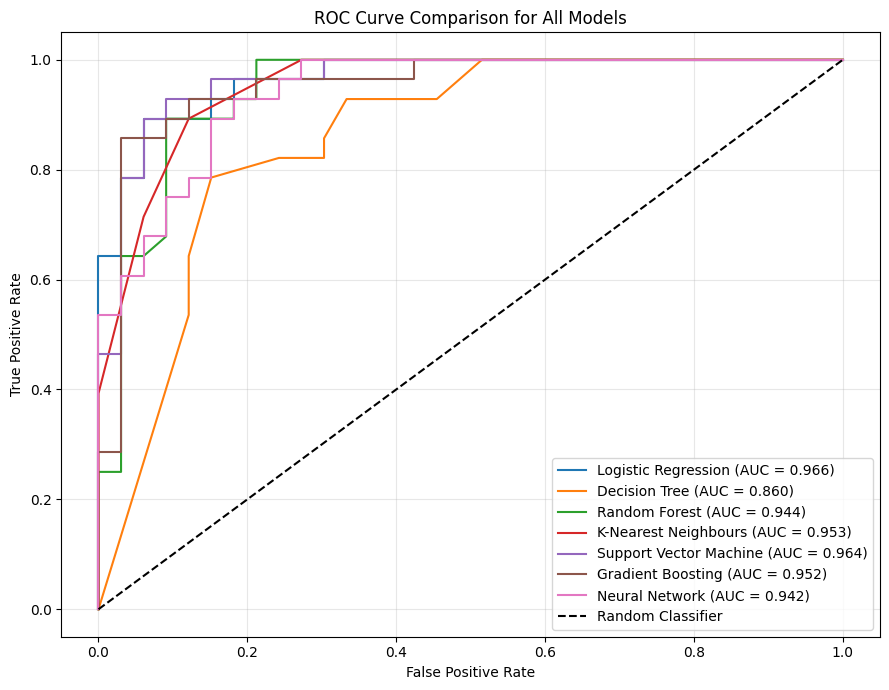

In [40]:
plt.figure(figsize=(9, 7))

for model_name, model_probabilities in probabilities_by_model.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        model_probabilities
    )
    model_auc = roc_auc_score(y_test, model_probabilities)
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC = {model_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for All Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
